# Train BACK SVM

Trains a binary SVM to detect background patches using:
- **Class 1 (Background):** CRC-100K BACK patches + TCGA white patches
- **Class 0 (Tissue):** Randomly sampled TCGA tissue patches

Training data source: `training_data_statistics_70_30.csv` (70% tissue / 30% background).

Outputs: `svm_model.pkl` and `scaler.pkl` saved to this folder.

## 1. Load Training Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
import joblib
from itertools import combinations

df = pd.read_csv("training_data_statistics_70_30.csv")

print(f"Total samples: {len(df)}")
print("\nLabel distribution:")
print(df["label"].value_counts().rename({0: "Tissue (0)", 1: "Background (1)"}))

Total samples: 11524

Label distribution:
label
Tissue (0)        8067
Background (1)    3457
Name: count, dtype: int64


## 2. Feature Distribution

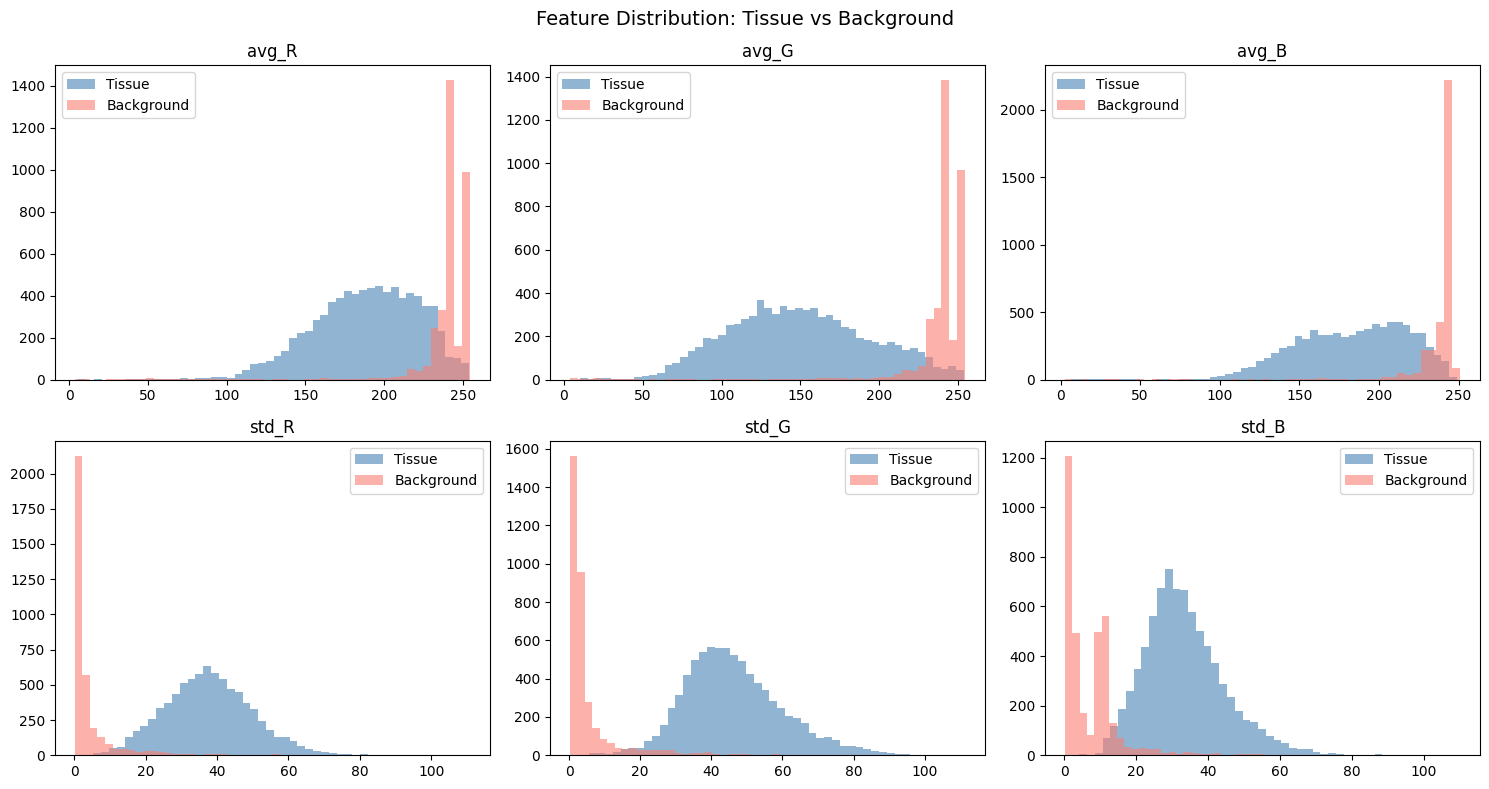

In [2]:
feature_cols = ['avg_R', 'avg_G', 'avg_B', 'std_R', 'std_G', 'std_B']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feat in enumerate(feature_cols):
    axes[i].hist(
        df[df['label'] == 0][feat], bins=50, alpha=0.6,
        label='Tissue', color='steelblue'
    )
    axes[i].hist(
        df[df['label'] == 1][feat], bins=50, alpha=0.6,
        label='Background', color='salmon'
    )
    axes[i].set_title(feat)
    axes[i].legend()

plt.suptitle('Feature Distribution: Tissue vs Background', fontsize=14)
plt.tight_layout()
plt.show()

## 3. Find Best Feature Combination

In [3]:
X_all = df[feature_cols].values
y = df["label"].values

X_train_all, X_test_all, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=42, stratify=y
)

results = []

for r in [3, 4, 5, 6]:
    for combo in combinations(range(len(feature_cols)), r):
        feat_names = [feature_cols[i] for i in combo]

        X_tr = X_train_all[:, combo]
        X_te = X_test_all[:, combo]

        scaler = StandardScaler()
        X_tr_scaled = scaler.fit_transform(X_tr)
        X_te_scaled = scaler.transform(X_te)

        svm = SVC(kernel='rbf', C=10, gamma='scale', class_weight='balanced', random_state=42)
        svm.fit(X_tr_scaled, y_train)
        acc = accuracy_score(y_test, svm.predict(X_te_scaled))

        results.append({
            'features': feat_names,
            'n_features': r,
            'accuracy': acc
        })

results_df = pd.DataFrame(results).sort_values('accuracy', ascending=False)
print("Top 10 feature combinations:")
print(results_df.head(10).to_string(index=False))

Top 10 feature combinations:
                                  features  n_features  accuracy
       [avg_R, avg_G, avg_B, std_G, std_B]           5  0.986985
[avg_R, avg_G, avg_B, std_R, std_G, std_B]           6  0.986117
       [avg_R, avg_G, std_R, std_G, std_B]           5  0.986117
              [avg_R, avg_G, std_G, std_B]           4  0.985249
       [avg_R, avg_G, avg_B, std_R, std_G]           5  0.984816
                     [avg_R, avg_G, std_G]           3  0.983514
              [avg_R, avg_G, std_R, std_G]           4  0.983514
              [avg_G, avg_B, std_R, std_G]           4  0.983080
              [avg_R, avg_G, avg_B, std_R]           4  0.982646
              [avg_R, avg_G, avg_B, std_G]           4  0.982646


## 4. Train Final Model with All 6 Features

In [4]:
FEATURE_COLS = ['avg_R', 'avg_G', 'avg_B', 'std_R', 'std_G', 'std_B']

X = df[FEATURE_COLS].values
y = df["label"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

svm_model = SVC(
    kernel='rbf',
    C=10,
    gamma='scale',
    class_weight='balanced',
    random_state=42
)
svm_model.fit(X_train_scaled, y_train)

print(f"Training complete. Support vectors: {svm_model.n_support_}")

Training complete. Support vectors: [321 148]


## 5. Evaluate

In [5]:
y_pred = svm_model.predict(X_test_scaled)

acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}\n")
print(classification_report(y_test, y_pred, target_names=['Tissue', 'Background']))

Accuracy: 0.9861

              precision    recall  f1-score   support

      Tissue       1.00      0.98      0.99      1614
  Background       0.96      0.99      0.98       691

    accuracy                           0.99      2305
   macro avg       0.98      0.99      0.98      2305
weighted avg       0.99      0.99      0.99      2305



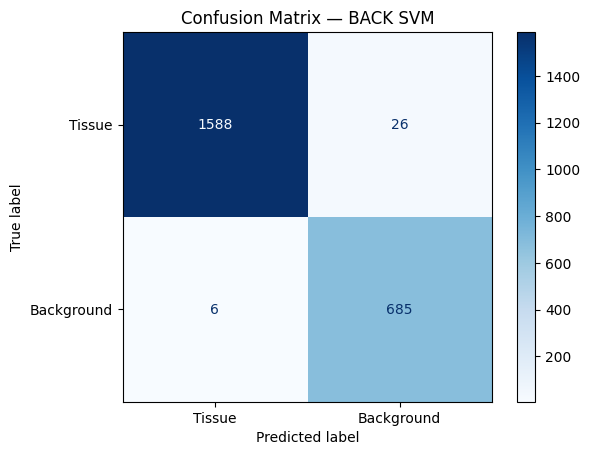

In [6]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Tissue', 'Background'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix — BACK SVM')
plt.show()

## 6. Save Model and Scaler

In [7]:
joblib.dump(svm_model, 'svm_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(FEATURE_COLS, 'feature_cols.pkl')

print("Saved:")
print("  svm_model.pkl")
print("  scaler.pkl")
print("  feature_cols.pkl")
print(f"\nModel details:")
print(f"  Kernel: {svm_model.kernel}")
print(f"  C: {svm_model.C}")
print(f"  Features: {FEATURE_COLS}")
print(f"  Test accuracy: {acc:.4f}")

Saved:
  svm_model.pkl
  scaler.pkl
  feature_cols.pkl

Model details:
  Kernel: rbf
  C: 10
  Features: ['avg_R', 'avg_G', 'avg_B', 'std_R', 'std_G', 'std_B']
  Test accuracy: 0.9861
